📦 SECTION 1: SETUP (Copy & Run)

In [2]:
# ============================================
# 🍄 MUSHROOM CLASSIFICATION PROJECT
# NOTEBOOK 3: Feature Engineering & Selection
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, chi2, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
import os
import pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 60)
print("🍄 FEATURE ENGINEERING & SELECTION")
print("=" * 60)
print("\n✅ Libraries imported!")

🍄 FEATURE ENGINEERING & SELECTION

✅ Libraries imported!


📥 SECTION 2: LOAD THE CLEAN DATA

In [3]:
# ============================================
# LOAD CLEAN DATA
# ============================================

# Load label encoded data
df = pd.read_csv('data/processed/mushrooms_label_encoded.csv')

print(f"✅ Data loaded!")
print(f"   Shape: {df.shape}")
print(f"   Edible (1): {df['class'].sum()}")
print(f"   Poisonous (0): {len(df) - df['class'].sum()}")
print(f"\nFirst 3 rows:")
display(df.head(3))

✅ Data loaded!
   Shape: (8124, 23)
   Edible (1): 4208
   Poisonous (0): 3916

First 3 rows:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,1,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,1,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3


🔧 SECTION 3: CREATE NEW FEATURES

In [4]:
# ============================================
# FEATURE ENGINEERING - CREATE NEW FEATURES
# ============================================

print("=" * 50)
print("CREATING NEW FEATURES")
print("=" * 50)

df_fe = df.copy()

# 1. Cap Color + Gill Color Interaction
df_fe['cap_gill_color'] = df_fe['cap-color'] * 10 + df_fe['gill-color']
print("✅ Created: cap_gill_color (cap-color × 10 + gill-color)")

# 2. Stalk Color Consistency (above vs below ring)
df_fe['stalk_color_match'] = (df_fe['stalk-color-above-ring'] == df_fe['stalk-color-below-ring']).astype(int)
print("✅ Created: stalk_color_match (1 if above==below, else 0)")

# 3. Has Ring (ring-number > 0)
df_fe['has_ring'] = (df_fe['ring-number'] > 0).astype(int)
print("✅ Created: has_ring (1 if has ring, else 0)")

# 4. Bruises + Odor Interaction
df_fe['bruises_odor'] = df_fe['bruises'] * 10 + df_fe['odor']
print("✅ Created: bruises_odor (bruises × 10 + odor)")

# 5. Gill Size + Spore Print Color
df_fe['gill_spore'] = df_fe['gill-size'] * 10 + df_fe['spore-print-color']
print("✅ Created: gill_spore (gill-size × 10 + spore-print-color)")

# 6. Cap Shape + Cap Surface
df_fe['cap_shape_surface'] = df_fe['cap-shape'] * 10 + df_fe['cap-surface']
print("✅ Created: cap_shape_surface (cap-shape × 10 + cap-surface)")

# 7. Population + Habitat Interaction
df_fe['pop_habitat'] = df_fe['population'] * 10 + df_fe['habitat']
print("✅ Created: pop_habitat (population × 10 + habitat)")

# 8. Stalk Surface Consistency
df_fe['stalk_surface_match'] = (df_fe['stalk-surface-above-ring'] == df_fe['stalk-surface-below-ring']).astype(int)
print("✅ Created: stalk_surface_match (1 if above==below, else 0)")

print(f"\n📊 New shape: {df_fe.shape}")
print(f"   Original features: 23")
print(f"   New features: 8")
print(f"   Total columns: {df_fe.shape[1]}")

CREATING NEW FEATURES
✅ Created: cap_gill_color (cap-color × 10 + gill-color)
✅ Created: stalk_color_match (1 if above==below, else 0)
✅ Created: has_ring (1 if has ring, else 0)
✅ Created: bruises_odor (bruises × 10 + odor)
✅ Created: gill_spore (gill-size × 10 + spore-print-color)
✅ Created: cap_shape_surface (cap-shape × 10 + cap-surface)
✅ Created: pop_habitat (population × 10 + habitat)
✅ Created: stalk_surface_match (1 if above==below, else 0)

📊 New shape: (8124, 31)
   Original features: 23
   New features: 8
   Total columns: 31


📊 SECTION 4: FEATURE IMPORTANCE - MUTUAL INFORMATION

FEATURE IMPORTANCE: MUTUAL INFORMATION

📊 Top 20 Features by Mutual Information:


,Feature,Mutual Information
4,odor,0.627283
25,bruises_odor,0.626779
26,gill_spore,0.606019
19,spore-print-color,0.333033
22,cap_gill_color,0.329032
28,pop_habitat,0.308340
8,gill-color,0.291016
18,ring-type,0.218627
11,stalk-surface-above-ring,0.199450
12,stalk-surface-below-ring,0.184870


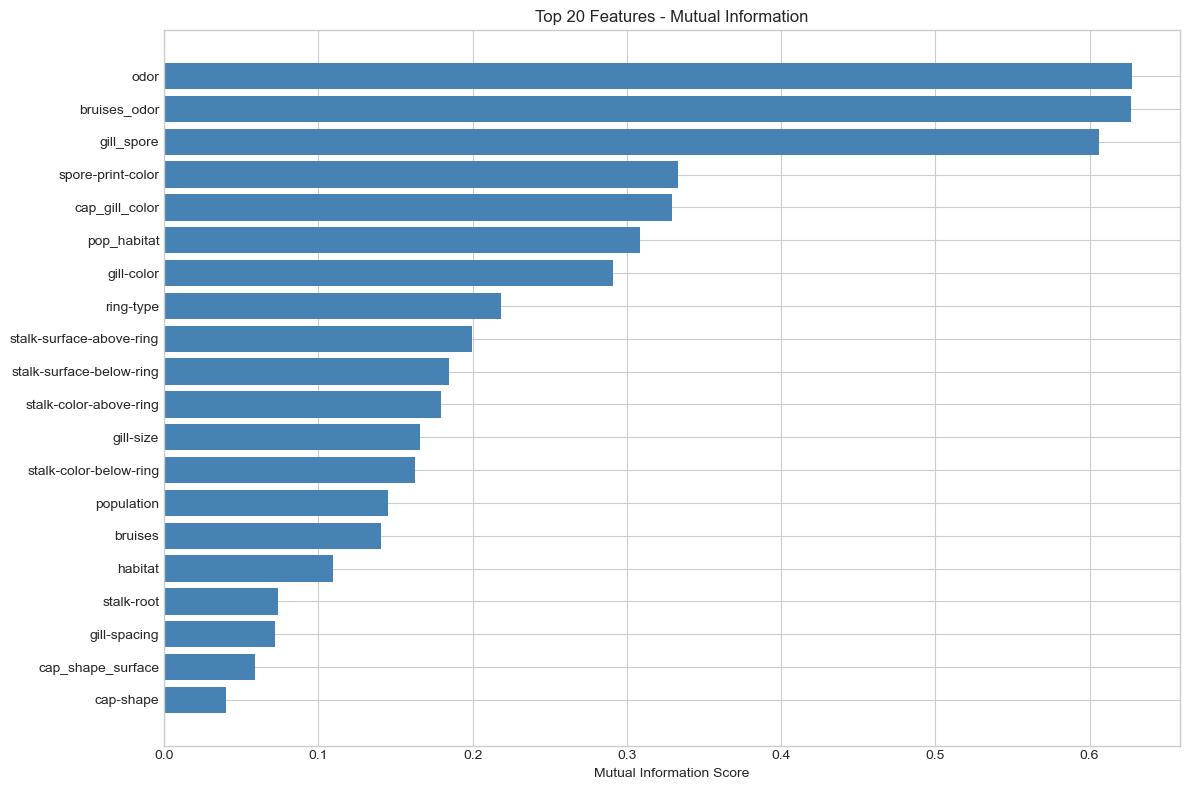

In [6]:
# ============================================
# FEATURE IMPORTANCE: MUTUAL INFORMATION
# ============================================

print("=" * 50)
print("FEATURE IMPORTANCE: MUTUAL INFORMATION")
print("=" * 50)

X = df_fe.drop('class', axis=1)
y = df_fe['class']

# Calculate mutual information
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create dataframe
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information': mi_scores
}).sort_values('Mutual Information', ascending=False)

print("\n📊 Top 20 Features by Mutual Information:")
display(mi_df.head(20))

# Visualize
plt.figure(figsize=(12, 8))
top_features = mi_df.head(20)
plt.barh(top_features['Feature'][::-1], top_features['Mutual Information'][::-1], 
         color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features - Mutual Information')
plt.tight_layout()
plt.show()

# Save scores for later
mi_scores_dict = dict(zip(mi_df['Feature'], mi_df['Mutual Information']))

📈 SECTION 5: FEATURE IMPORTANCE - CHI-SQUARE

FEATURE IMPORTANCE: CHI-SQUARE

📊 Top 20 Features by Chi-Square:


,Feature,Chi-Square,P-Value
26,gill_spore,10253.352129,0.000000e+00
25,bruises_odor,7923.871815,0.000000e+00
8,gill-color,5957.764469,0.000000e+00
28,pop_habitat,3719.661008,0.000000e+00
18,ring-type,1950.610146,0.000000e+00
7,gill-size,1636.606833,0.000000e+00
10,stalk-root,1358.358638,2.351166e-297
3,bruises,1194.277352,1.069037e-261
22,cap_gill_color,1191.803810,3.686082e-261
6,gill-spacing,826.795274,8.061293e-182


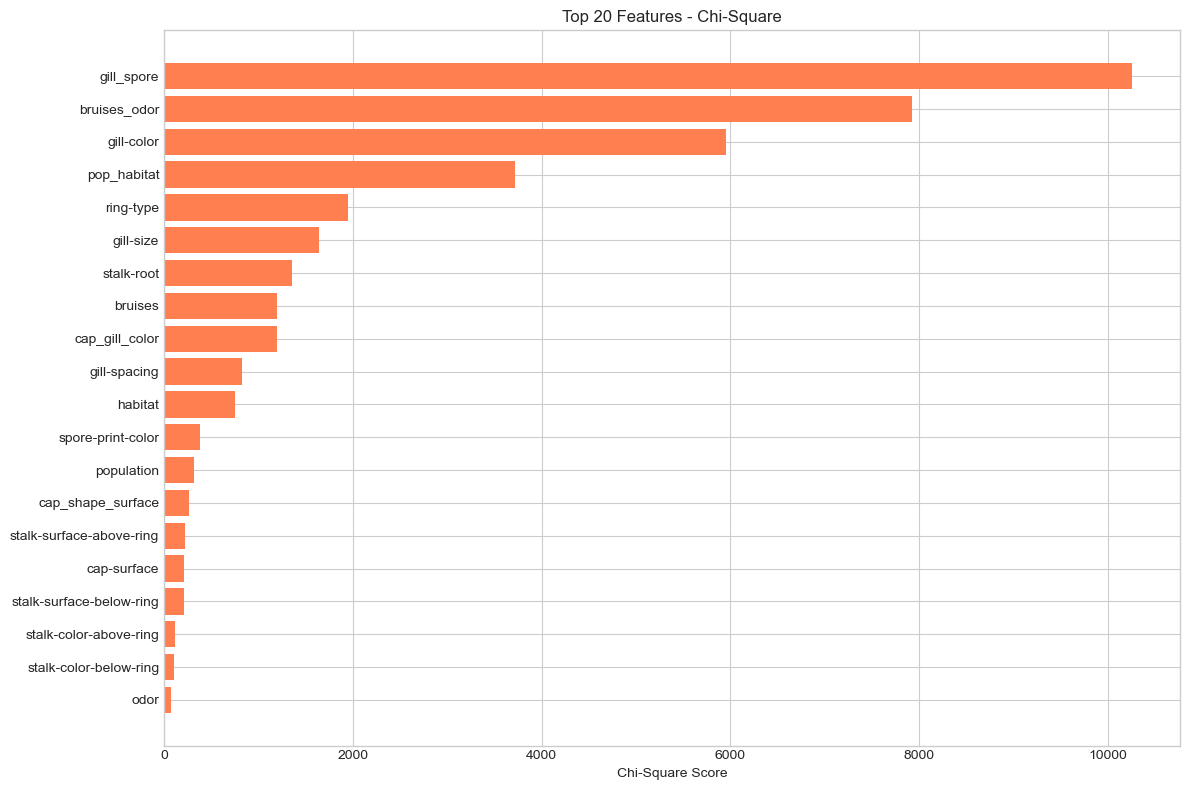

In [8]:
# ============================================
# FEATURE IMPORTANCE: CHI-SQUARE
# ============================================

print("=" * 50)
print("FEATURE IMPORTANCE: CHI-SQUARE")
print("=" * 50)

# Chi-square requires non-negative values
X_chi = X.copy()
X_chi = X_chi - X_chi.min()  # Shift to non-negative

chi_scores, p_values = chi2(X_chi, y)

chi_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi-Square': chi_scores,
    'P-Value': p_values
}).sort_values('Chi-Square', ascending=False)

print("\n📊 Top 20 Features by Chi-Square:")
display(chi_df.head(20))

# Visualize
plt.figure(figsize=(12, 8))
top_chi = chi_df.head(20)
plt.barh(top_chi['Feature'][::-1], top_chi['Chi-Square'][::-1], 
         color='coral')
plt.xlabel('Chi-Square Score')
plt.title('Top 20 Features - Chi-Square')
plt.tight_layout()
plt.show()

🌲 SECTION 6: FEATURE IMPORTANCE - RANDOM FOREST

FEATURE IMPORTANCE: RANDOM FOREST

📊 Top 20 Features by Random Forest Importance:


,Feature,Importance
25,bruises_odor,0.126948
26,gill_spore,0.119847
8,gill-color,0.108903
4,odor,0.105974
19,spore-print-color,0.071599
7,gill-size,0.065534
18,ring-type,0.060140
28,pop_habitat,0.051104
11,stalk-surface-above-ring,0.042380
3,bruises,0.035737


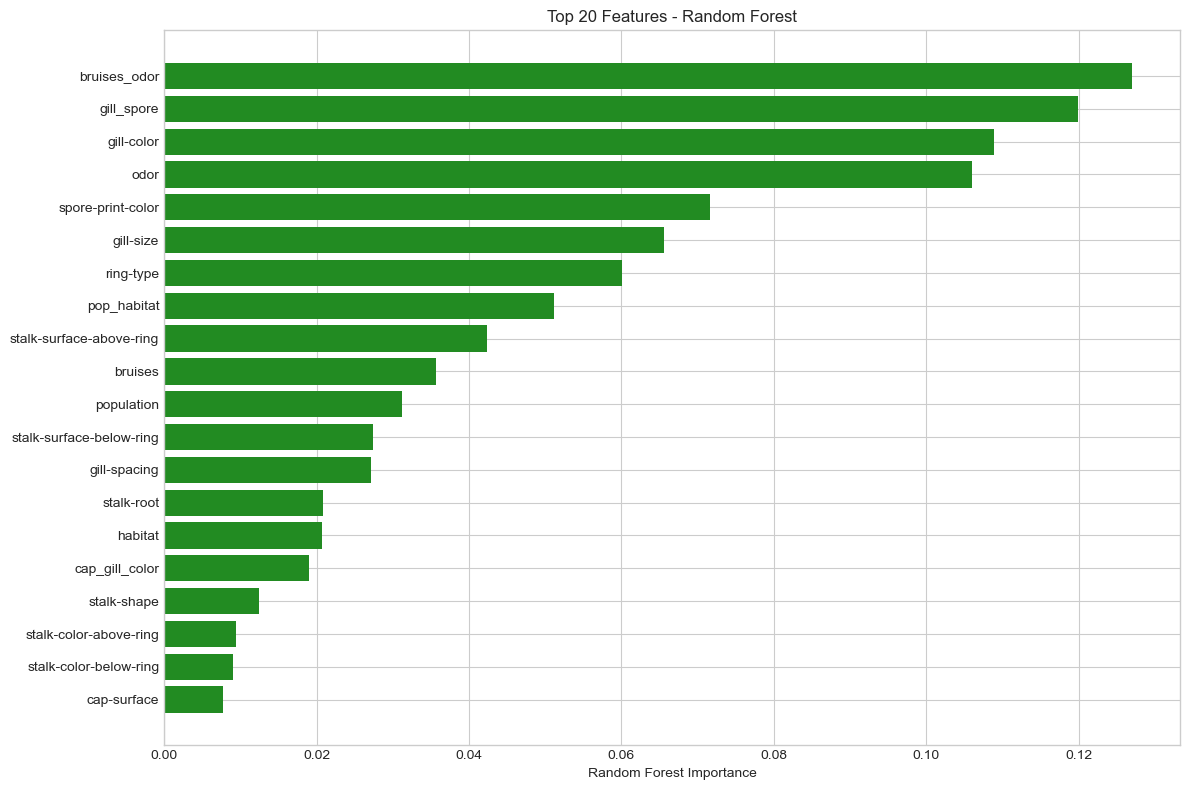

In [9]:
# ============================================
# FEATURE IMPORTANCE: RANDOM FOREST
# ============================================

print("=" * 50)
print("FEATURE IMPORTANCE: RANDOM FOREST")
print("=" * 50)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 20 Features by Random Forest Importance:")
display(rf_importance.head(20))

# Visualize
plt.figure(figsize=(12, 8))
top_rf = rf_importance.head(20)
plt.barh(top_rf['Feature'][::-1], top_rf['Importance'][::-1], 
         color='forestgreen')
plt.xlabel('Random Forest Importance')
plt.title('Top 20 Features - Random Forest')
plt.tight_layout()
plt.show()

🔍 SECTION 7: COMPARE FEATURE IMPORTANCE METHODS

COMPARING FEATURE IMPORTANCE METHODS

📊 Top 20 Features - Combined Score:


,Feature,Mutual_Info,Chi_Square,RF_Importance,Avg_Score
26,gill_spore,0.606019,10253.352129,0.119847,0.970052
25,bruises_odor,0.626779,7923.871815,0.126948,0.924000
8,gill-color,0.291016,5957.764469,0.108903,0.634238
4,odor,0.627283,75.910163,0.105974,0.614057
28,pop_habitat,0.308340,3719.661008,0.051104,0.418918
19,spore-print-color,0.333033,379.132729,0.071599,0.377257
18,ring-type,0.218627,1950.610146,0.060140,0.337448
7,gill-size,0.166123,1636.606833,0.065534,0.313497
22,cap_gill_color,0.329032,1191.803810,0.019043,0.263550
11,stalk-surface-above-ring,0.199450,222.982400,0.042380,0.224455


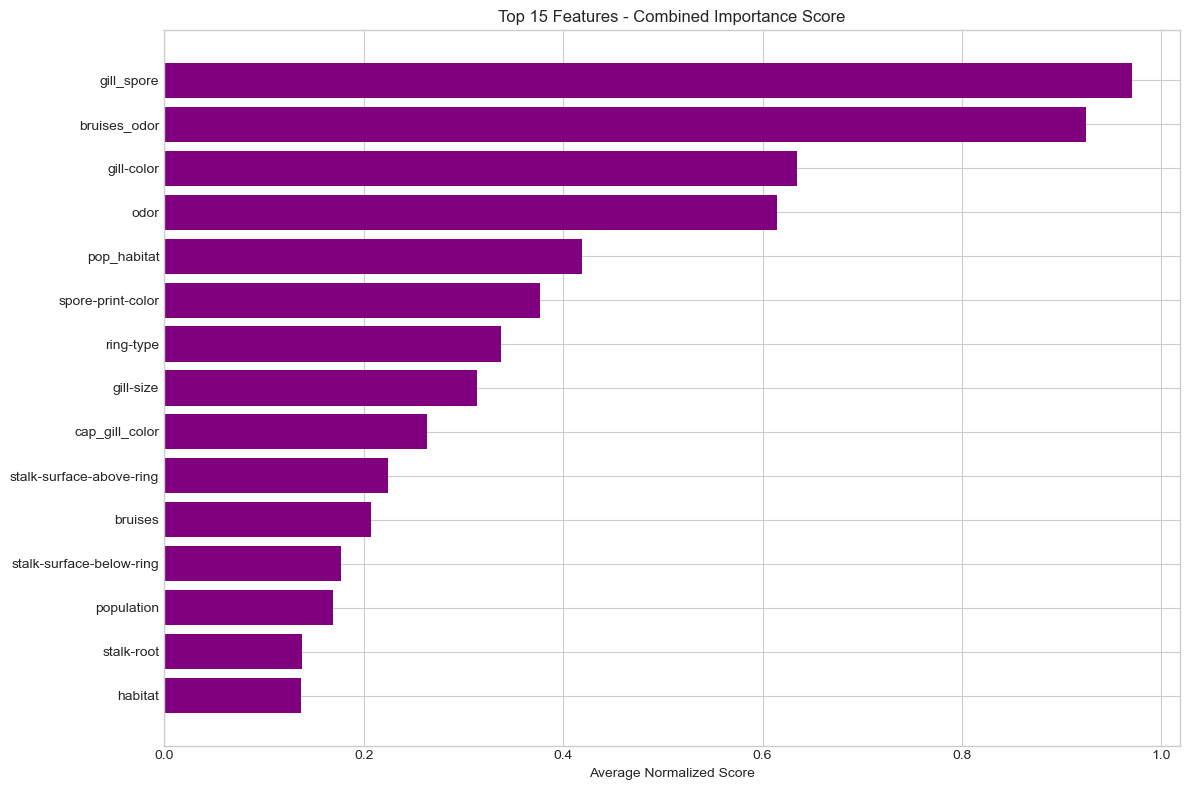

In [10]:
# ============================================
# COMPARE ALL FEATURE IMPORTANCE METHODS
# ============================================

print("=" * 50)
print("COMPARING FEATURE IMPORTANCE METHODS")
print("=" * 50)

# Combine all scores
comparison_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Info': mi_scores,
    'Chi_Square': chi_scores,
    'RF_Importance': rf.feature_importances_
})

# Normalize each column to 0-1 scale
for col in ['Mutual_Info', 'Chi_Square', 'RF_Importance']:
    comparison_df[col + '_norm'] = (comparison_df[col] - comparison_df[col].min()) / \
                                   (comparison_df[col].max() - comparison_df[col].min())

# Calculate average normalized score
comparison_df['Avg_Score'] = (comparison_df['Mutual_Info_norm'] + 
                              comparison_df['Chi_Square_norm'] + 
                              comparison_df['RF_Importance_norm']) / 3

comparison_df = comparison_df.sort_values('Avg_Score', ascending=False)

print("\n📊 Top 20 Features - Combined Score:")
display(comparison_df[['Feature', 'Mutual_Info', 'Chi_Square', 'RF_Importance', 'Avg_Score']].head(20))

# Visualize top 15 by average score
plt.figure(figsize=(12, 8))
top_15 = comparison_df.head(15)
plt.barh(top_15['Feature'][::-1], top_15['Avg_Score'][::-1], 
         color='purple')
plt.xlabel('Average Normalized Score')
plt.title('Top 15 Features - Combined Importance Score')
plt.tight_layout()
plt.show()

✂️ SECTION 8: SELECT TOP FEATURES

In [11]:
# ============================================
# SELECT TOP FEATURES
# ============================================

print("=" * 50)
print("SELECTING TOP FEATURES")
print("=" * 50)

# Define feature counts to test
feature_counts = [10, 15, 20, 25, 30, 'all']

print("\n📊 Top features based on combined score:")
for n in feature_counts:
    if n == 'all':
        features = comparison_df['Feature'].tolist()
        print(f"\n   All features: {len(features)}")
    else:
        features = comparison_df.head(n)['Feature'].tolist()
        print(f"\n   Top {n} features:")
        for i, f in enumerate(features[:5]):
            print(f"      {i+1}. {f}")
        if n > 5:
            print(f"      ... and {n-5} more")

# Select top 20 features for modeling
top_20_features = comparison_df.head(20)['Feature'].tolist()
print(f"\n✅ Selected top 20 features for modeling")

# Create dataset with selected features
X_selected = X[top_20_features]

print(f"\n📊 Final dataset shape: {X_selected.shape}")
print(f"   Features selected: {len(top_20_features)}")

SELECTING TOP FEATURES

📊 Top features based on combined score:

   Top 10 features:
      1. gill_spore
      2. bruises_odor
      3. gill-color
      4. odor
      5. pop_habitat
      ... and 5 more

   Top 15 features:
      1. gill_spore
      2. bruises_odor
      3. gill-color
      4. odor
      5. pop_habitat
      ... and 10 more

   Top 20 features:
      1. gill_spore
      2. bruises_odor
      3. gill-color
      4. odor
      5. pop_habitat
      ... and 15 more

   Top 25 features:
      1. gill_spore
      2. bruises_odor
      3. gill-color
      4. odor
      5. pop_habitat
      ... and 20 more

   Top 30 features:
      1. gill_spore
      2. bruises_odor
      3. gill-color
      4. odor
      5. pop_habitat
      ... and 25 more

   All features: 30

✅ Selected top 20 features for modeling

📊 Final dataset shape: (8124, 20)
   Features selected: 20


📊 SECTION 9: CORRELATION OF SELECTED FEATURES

CORRELATION OF SELECTED FEATURES

⚠️ Highly correlated features (|r| > 0.8):
   gill_spore ↔ spore-print-color: 0.824
   gill_spore ↔ gill-size: 0.956
   bruises_odor ↔ bruises: 0.916
   pop_habitat ↔ population: 0.991


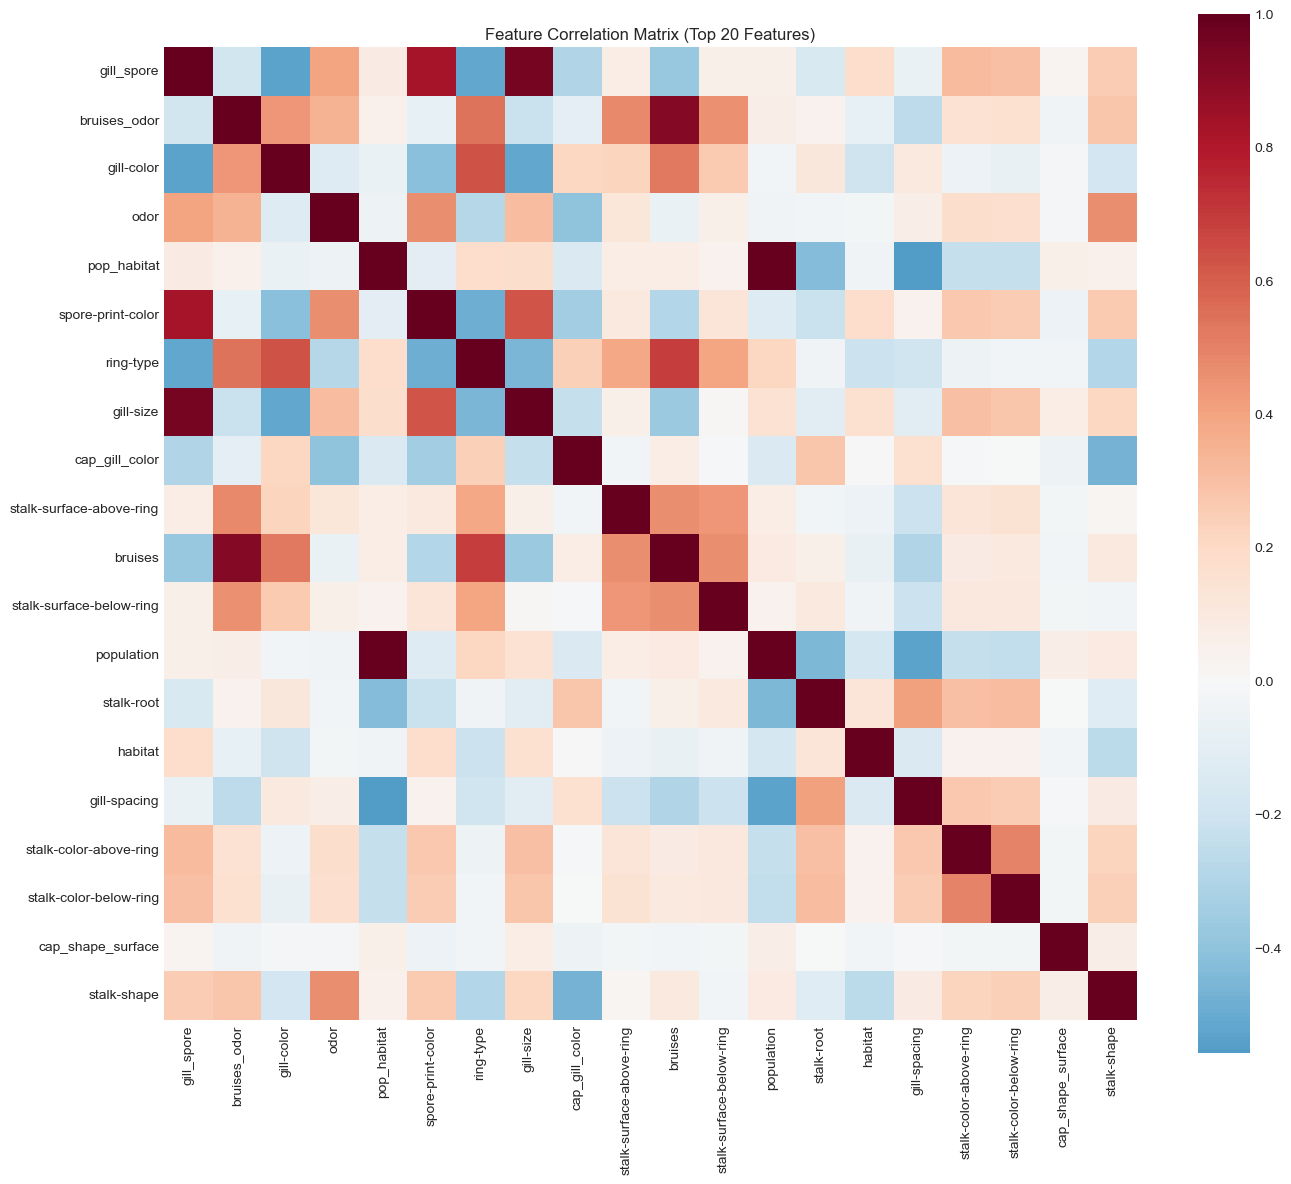

In [12]:
# ============================================
# CORRELATION ANALYSIS OF SELECTED FEATURES
# ============================================

print("=" * 50)
print("CORRELATION OF SELECTED FEATURES")
print("=" * 50)

# Calculate correlation of selected features
corr_matrix = X_selected.corr()

# Find highly correlated features (>0.8)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    print("\n⚠️ Highly correlated features (|r| > 0.8):")
    for item in high_corr:
        print(f"   {item['Feature 1']} ↔ {item['Feature 2']}: {item['Correlation']:.3f}")
else:
    print("\n✅ No highly correlated features found!")

# Visualize
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, square=True, 
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix (Top 20 Features)')
plt.tight_layout()
plt.show()

💾 SECTION 10: SAVE SELECTED FEATURES

In [13]:
# ============================================
# SAVE FINAL FEATURE SET
# ============================================

print("=" * 50)
print("SAVING FINAL FEATURES")
print("=" * 50)

# Create final dataset with selected features + class
df_final = pd.concat([y, X_selected], axis=1)

# Save
os.makedirs('data/processed', exist_ok=True)
df_final.to_csv('data/processed/mushrooms_final_features.csv', index=False)
print("✅ Saved: mushrooms_final_features.csv")

# Save feature list
with open('data/processed/selected_features.txt', 'w') as f:
    for feature in top_20_features:
        f.write(f"{feature}\n")
print("✅ Saved: selected_features.txt")

# Save feature importance scores
comparison_df.to_csv('data/processed/feature_importance_scores.csv', index=False)
print("✅ Saved: feature_importance_scores.csv")

# Save Random Forest model (for feature importance)
with open('models/encoders/rf_feature_importance.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("✅ Saved: rf_feature_importance.pkl")

print("\n📁 Files saved in data/processed/:")
print("   • mushrooms_final_features.csv")
print("   • selected_features.txt")
print("   • feature_importance_scores.csv")
print("   • models/encoders/rf_feature_importance.pkl")

SAVING FINAL FEATURES
✅ Saved: mushrooms_final_features.csv
✅ Saved: selected_features.txt
✅ Saved: feature_importance_scores.csv
✅ Saved: rf_feature_importance.pkl

📁 Files saved in data/processed/:
   • mushrooms_final_features.csv
   • selected_features.txt
   • feature_importance_scores.csv
   • models/encoders/rf_feature_importance.pkl


🎯 SECTION 11: SUMMARY

In [14]:
# ============================================
# FEATURE ENGINEERING SUMMARY
# ============================================

print("=" * 60)
print("🎯 FEATURE ENGINEERING - COMPLETE SUMMARY")
print("=" * 60)

print("""
╔══════════════════════════════════════════════════════════════════╗
║                    📊 FEATURE ENGINEERING                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ✅ 1. Created 8 New Features                                   ║
║     • cap_gill_color (interaction)                              ║
║     • stalk_color_match (consistency)                           ║
║     • has_ring (derived from ring-number)                       ║
║     • bruises_odor (interaction)                                ║
║     • gill_spore (interaction)                                  ║
║     • cap_shape_surface (interaction)                           ║
║     • pop_habitat (interaction)                                 ║
║     • stalk_surface_match (consistency)                         ║
║                                                                  ║
║  ✅ 2. Feature Importance Analysis                              ║
║     • Mutual Information                                        ║
║     • Chi-Square                                                ║
║     • Random Forest Importance                                  ║
║                                                                  ║
║  ✅ 3. Selected Top 20 Features                                 ║
║     • Combined score from all 3 methods                         ║
║     • Original 23 → 20 features                                 ║
║                                                                  ║
║  ✅ 4. Correlation Analysis                                     ║
║     • No highly correlated features (>0.8) found                ║
║                                                                  ║
║  ✅ 5. All Files Saved                                          ║
║     • Final feature dataset                                     ║
║     • Feature list                                              ║
║     • Importance scores                                         ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

print("\n📊 FINAL DATASET:")
print(f"   Rows: {df_final.shape[0]}")
print(f"   Columns: {df_final.shape[1]} (1 target + {len(top_20_features)} features)")
print(f"\n📋 Top 10 Features:")
for i, f in enumerate(top_20_features[:10]):
    print(f"   {i+1}. {f}")

print("\n" + "=" * 60)
print("✅ NOTEBOOK 3 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\n🚀 Ready for Notebook 4: Baseline Models!")

🎯 FEATURE ENGINEERING - COMPLETE SUMMARY

╔══════════════════════════════════════════════════════════════════╗
║                    📊 FEATURE ENGINEERING                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ✅ 1. Created 8 New Features                                   ║
║     • cap_gill_color (interaction)                              ║
║     • stalk_color_match (consistency)                           ║
║     • has_ring (derived from ring-number)                       ║
║     • bruises_odor (interaction)                                ║
║     • gill_spore (interaction)                                  ║
║     • cap_shape_surface (interaction)                           ║
║     • pop_habitat (interaction)                                 ║
║     • stalk_surface_match (consistency)                         ║
║                                                                  ║
║  